In [130]:
import numpy as np
import matplotlib.pyplot as plt

In [131]:
#Defining earth
# Earth parameters

R_EARTH = 6_378_137.0       # Earth radius [m](We're using the WGS-84 equatorial radius for now.)
MU_EARTH = 3.986004418e14   # Earth's gravitational parameter [m^3/s^2]

In [132]:
# Satellite altitudes

LEO_ALTITUDE = 600e3       # 600 km
MEO_ALTITUDE = 20_200e3    # 20,200 km

In [133]:
LEO_PHASE = 0.0
MEO_PHASE = np.deg2rad(90)

# V2 : Full orbital orientaion

            Full pipeline:
             Six orbital elements
        ┌──────────────────────────┐
        │ a  e  i  Ω  ω  ν          │
        └────────────┬─────────────┘
                     │
                     ▼
             Orbital-plane state
                 (PQW frame)
                     │
                     ▼
             Rotate orbital plane
                     │
              R₃(Ω) R₁(i) R₃(ω)
                     │
                     ▼
                ECI state
               r(t), v(t)


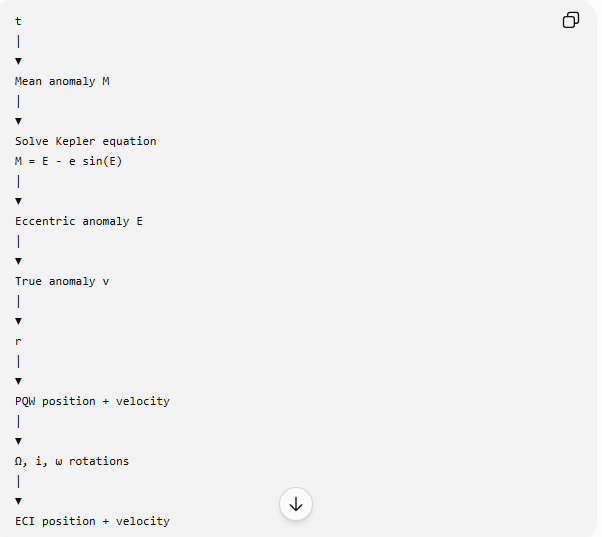

In [134]:
def solve_keplers_equation(M, e, tolerance=1e-12, max_iterations=100):
    """
    Solve M = E - e*sin(E) for eccentric anomaly E.
    """

    # Initial guess
    E = M if e < 0.8 else np.pi

    for _ in range(max_iterations):

        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)

        delta_E = f / f_prime
        E -= delta_E

        if abs(delta_E) < tolerance:
            break

    return E

In [135]:
def eccentric_to_true_anomaly(E, e):

    numerator = np.sqrt(1 + e) * np.sin(E / 2)
    denominator = np.sqrt(1 - e) * np.cos(E / 2)

    nu = 2 * np.arctan2(numerator, denominator)

    return nu

In [136]:
def rotation_1(angle):
    """
    Rotation about x-axis.
    """

    c = np.cos(angle)
    s = np.sin(angle)

    return np.array([
        [1, 0, 0],
        [0, c, -s],
        [0, s,  c]
    ])


def rotation_3(angle):
    """
    Rotation about z-axis.
    """

    c = np.cos(angle)
    s = np.sin(angle)

    return np.array([
        [ c, -s, 0],
        [ s,  c, 0],
        [ 0,  0, 1]
    ])

# Actual orbital-elements propagator

In [137]:
def orbital_elements_to_state(
    a,
    e,
    inclination,
    raan,
    arg_periapsis,
    true_anomaly
):

    # ------------------------------------------------
    # 1. Calculate orbital radius
    # ------------------------------------------------

    r = (
        a * (1 - e**2)
        / (1 + e * np.cos(true_anomaly))
    )

    # ------------------------------------------------
    # 2. Position in PQW frame
    # ------------------------------------------------

    position_pqw = np.array([
        r * np.cos(true_anomaly),
        r * np.sin(true_anomaly),
        0.0
    ])

    # ------------------------------------------------
    # 3. Velocity in PQW frame
    # ------------------------------------------------

    velocity_factor = np.sqrt(
        MU_EARTH / (a * (1 - e**2))
    )

    velocity_pqw = velocity_factor * np.array([
        -np.sin(true_anomaly),
        e + np.cos(true_anomaly),
        0.0
    ])

    # ------------------------------------------------
    # 4. Rotate PQW → ECI
    # ------------------------------------------------

    transformation = (
        rotation_3(raan)
        @ rotation_1(inclination)
        @ rotation_3(arg_periapsis)
    )

    position_eci = transformation @ position_pqw
    velocity_eci = transformation @ velocity_pqw

    return position_eci, velocity_eci

In [138]:
#propegator
def propagate_orbit(
    a,
    e,
    inclination,
    raan,
    arg_periapsis,
    true_anomaly_0,
    times
):

    # Initial eccentric anomaly
    E0 = 2 * np.arctan2(
        np.sqrt(1 - e) * np.sin(true_anomaly_0 / 2),
        np.sqrt(1 + e) * np.cos(true_anomaly_0 / 2)
    )

    # Initial mean anomaly
    M0 = E0 - e * np.sin(E0)

    # Mean motion
    n = np.sqrt(MU_EARTH / a**3)

    positions = []
    velocities = []

    for t in times:

        # Mean anomaly at time t
        M = M0 + n * t

        # Normalize to [0, 2π)
        M = M % (2 * np.pi)

        # Solve Kepler's equation
        E = solve_keplers_equation(M, e)

        # Convert to true anomaly
        nu = eccentric_to_true_anomaly(E, e)

        # Convert orbital elements to ECI state
        position, velocity = orbital_elements_to_state(
            a,
            e,
            inclination,
            raan,
            arg_periapsis,
            nu
        )

        positions.append(position)
        velocities.append(velocity)

    return (
        np.array(positions),
        np.array(velocities)
    )

In [139]:
LEO_a = R_EARTH + 600e3
LEO_e = 0.01

LEO_i = np.deg2rad(53)

LEO_raan = np.deg2rad(40)

LEO_arg_periapsis = np.deg2rad(30)

LEO_true_anomaly_0 = np.deg2rad(0)

In [140]:
MEO_a = R_EARTH + 20_200e3
MEO_e = 0.01
MEO_i = np.deg2rad(55)
MEO_raan = np.deg2rad(120)
MEO_arg_periapsis = np.deg2rad(45)
MEO_true_anomaly_0 = np.deg2rad(180)

In [141]:
simulation_time = 24 * 3600
num_steps = 3000

times = np.linspace(
    0,
    simulation_time,
    num_steps
)

leo_positions, leo_velocities = propagate_orbit(
    LEO_a,
    LEO_e,
    LEO_i,
    LEO_raan,
    LEO_arg_periapsis,
    LEO_true_anomaly_0,
    times
)
MEO_positions, MEO_velocities = propagate_orbit(
    MEO_a,
    MEO_e,
    MEO_i,
    MEO_raan,
    MEO_arg_periapsis,
    MEO_true_anomaly_0,
    times
)

In [145]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=leo_positions[:, 0] / 1e3,
        y=leo_positions[:, 1] / 1e3,
        z=leo_positions[:, 2] / 1e3,
        mode="lines",
        name="LEO Orbit"
    )
)
fig.add_trace(
    go.Scatter3d(
        x=MEO_positions[:, 0] / 1e3,
        y=MEO_positions[:, 1] / 1e3,
        z=MEO_positions[:, 2] / 1e3,
        mode="lines",
        name="MEO Orbit"
    )

)
fig.update_layout(
    width=1000,
    height=1000,
    scene=dict(
        xaxis_title="X [km]",
        yaxis_title="Y [km]",
        zaxis_title="Z [km]"
    ),
    title="V2 — Full Orbital-Element LEO and MEO"
)

fig.show()

testing eccentricity works

In [143]:
leo_radii = np.linalg.norm(
    leo_positions,
    axis=1
)

print(
    "Minimum radius:",
    np.min(leo_radii) / 1e3,
    "km"
)

print(
    "Maximum radius:",
    np.max(leo_radii) / 1e3,
    "km"
)

Minimum radius: 6908.355629999999 km
Maximum radius: 7047.918324153442 km


In [146]:
leo_speeds = np.linalg.norm(
    leo_velocities,
    axis=1
)

MEO_speeds = np.linalg.norm(
    MEO_velocities,
    axis=1
)

print(
    "LEO speed:",
    np.min(leo_speeds),
    "to",
    np.max(leo_speeds),
    "m/s"
)

print(
    "MEO speed:",
    np.min(MEO_speeds),
    "to",
    np.max(MEO_speeds),
    "m/s"
)


LEO speed: 7482.660746022331 to 7633.8255594188695 m/s
MEO speed: 3834.1008348907217 to 3911.5574056226737 m/s
